# Exercise 5

## Part (a)

In [2]:
x1=runif (500) -0.5
x2=runif (500) -0.5
y=1*(x1^2-x2^2 > 0)

## Part (b)

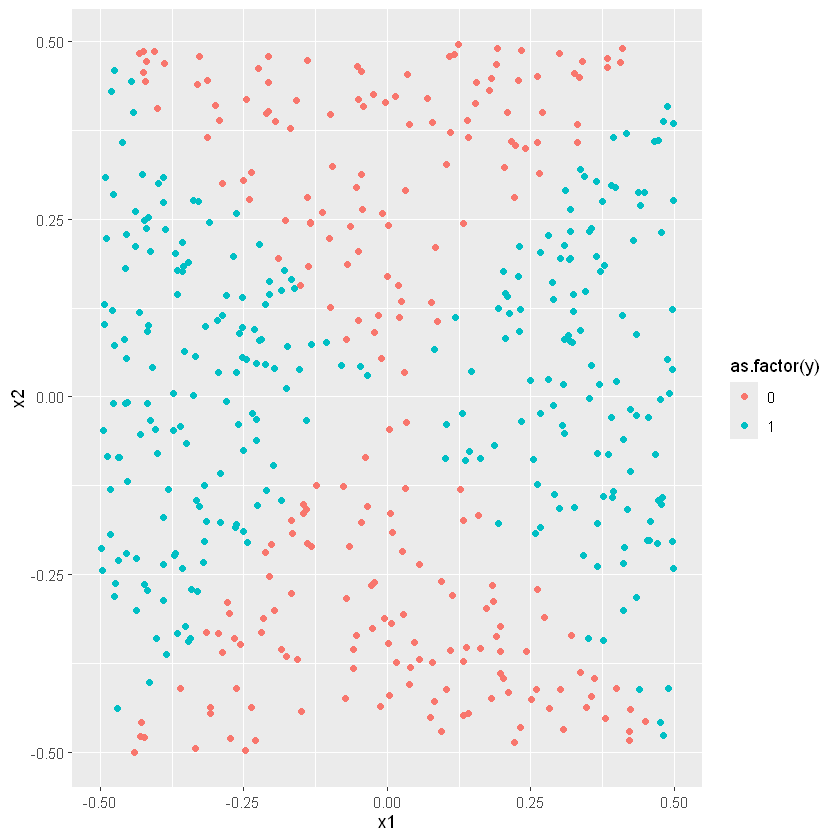

In [4]:
library(ggplot2)

data = data.frame(x1=x1, x2=x2, y=y)
ggplot(data, aes(x=x1, y=x2, col=as.factor(y))) + geom_point()

## Part (c)

In [26]:
log_model = glm(y~x1+x2, data, family="binomial")
summary(log_model)


Call:
glm(formula = y ~ x1 + x2, family = "binomial", data = data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)  
(Intercept)  0.18694    0.09011   2.074    0.038 *
x1          -0.26052    0.29583  -0.881    0.379  
x2           0.30079    0.31754   0.947    0.344  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 688.53  on 499  degrees of freedom
Residual deviance: 686.85  on 497  degrees of freedom
AIC: 692.85

Number of Fisher Scoring iterations: 4


## Part (d)

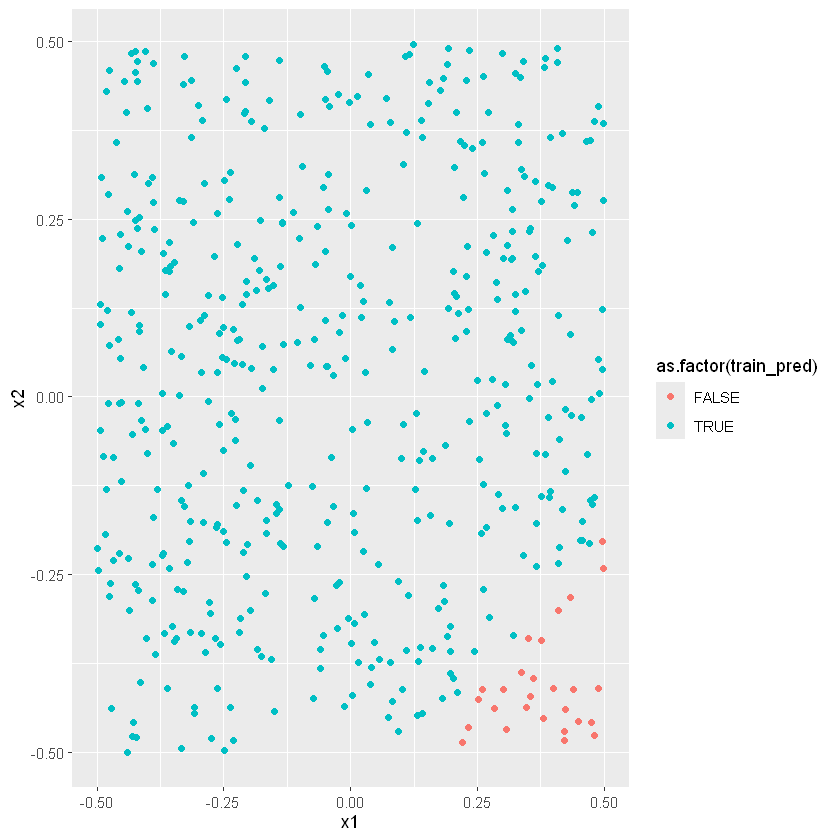

In [41]:
train_probs = predict(log_model, newdata=data, type="response")
train_pred = train_probs>0.5

ggplot(data, aes(x=x1, y=x2, col=as.factor(train_pred))) + geom_point()

## Part (e)

In [62]:
nonlin_log = glm(y~I(x1^2) + I(x2^2) + I(x1*x2), data, family="binomial")
summary(nonlin_log)

Warning message:
"glm.fit: algorithm did not converge"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"



Call:
glm(formula = y ~ I(x1^2) + I(x2^2) + I(x1 * x2), family = "binomial", 
    data = data)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept)     -3.345    163.246  -0.020    0.984
I(x1^2)      69851.578 830954.655   0.084    0.933
I(x2^2)     -69185.171 819546.684  -0.084    0.933
I(x1 * x2)     305.786  70776.457   0.004    0.997

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 6.8853e+02  on 499  degrees of freedom
Residual deviance: 3.9326e-05  on 496  degrees of freedom
AIC: 8

Number of Fisher Scoring iterations: 25


## Part (f)

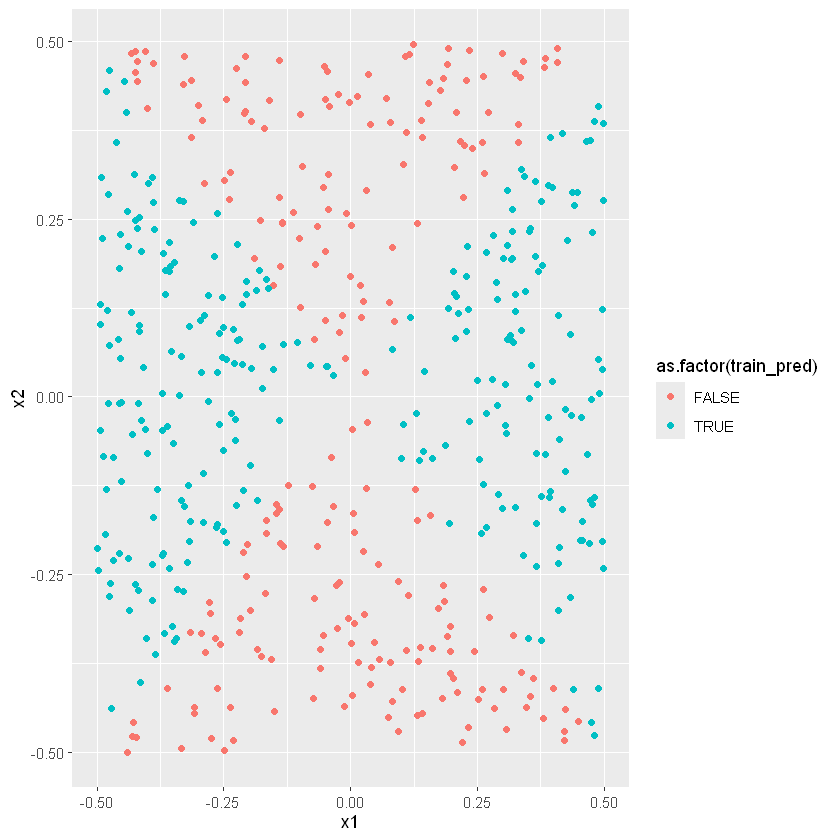

In [91]:
train_probs = predict(nonlin_log, newdata=data, type="response")
train_pred = train_probs>0.5

ggplot(data, aes(x=x1, y=x2, col=as.factor(train_pred))) + geom_point()

In [93]:
print("Accuracy:")
mean(train_pred==y)

[1] "Accuracy:"


[1] 1

## Part (g)

In [75]:
library(e1071)
data$y = as.factor(y)

svc = svm(y~., data, kernel="linear")
summary(svc)


Call:
svm(formula = y ~ ., data = data, kernel = "linear")


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  linear 
       cost:  1 

Number of Support Vectors:  459

 ( 226 233 )


Number of Classes:  2 

Levels: 
 0 1




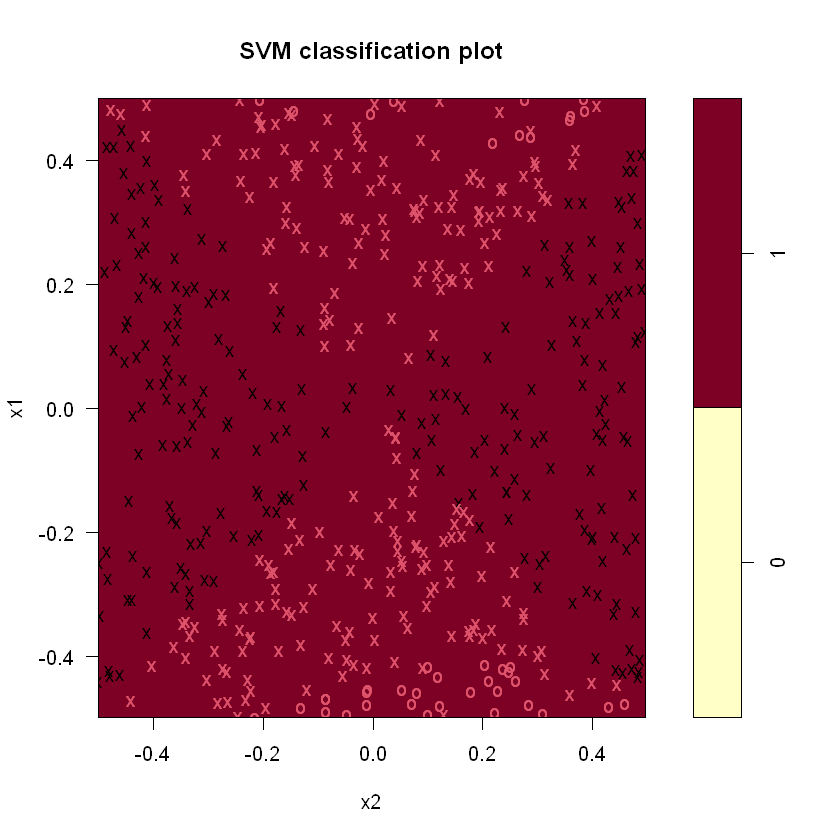

In [77]:
plot(svc,data)

## Part (h)

In [88]:
svmfit = svm(y~., data, kernel="polynomial", degree=2)
summary(svmfit)


Call:
svm(formula = y ~ ., data = data, kernel = "polynomial", degree = 2)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  polynomial 
       cost:  1 
     degree:  2 
     coef.0:  0 

Number of Support Vectors:  128

 ( 64 64 )


Number of Classes:  2 

Levels: 
 0 1




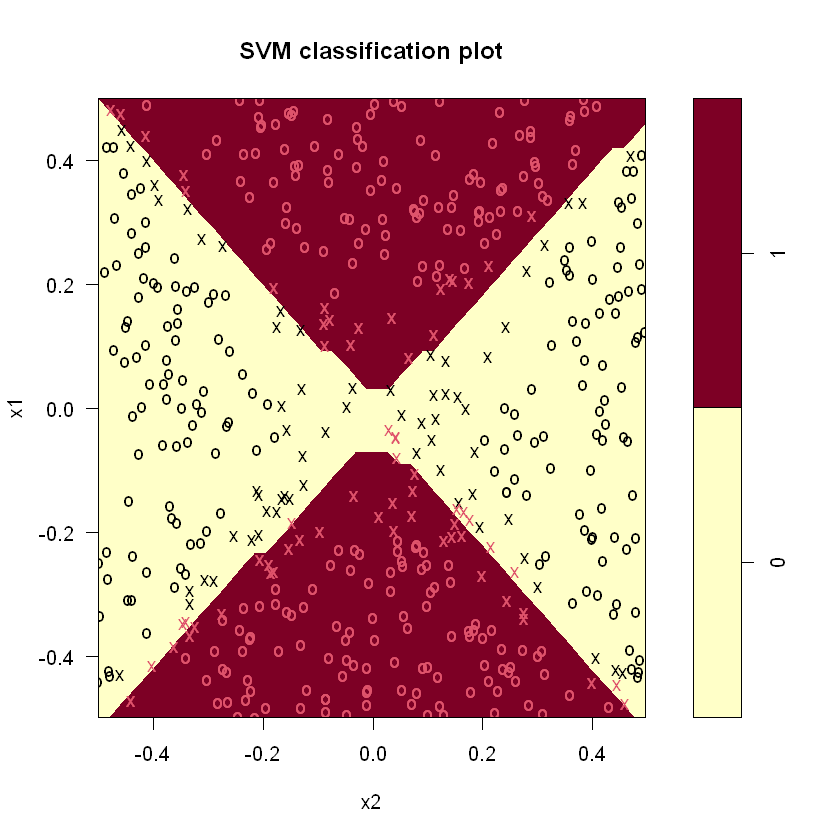

In [95]:
plot(svmfit,data)

In [97]:
print("Accuracy:")
mean(predict(svmfit, newdata=data, type="response")==y)

[1] "Accuracy:"


[1] 0.97

## Part (i)

The logistic regression was much better at predicting the boundary with a train accuracy of 100%. It was interesting to note that the algorithm did not converge, which makes sense I guess, because with $X_1^2$ and $X_2^2$ as predictors - the decision line would be extremely accurate resulting in econfident predictions of 0 and 1. If we think about the mathematical form of the logisitc regression, we see that for a prediction to be 0, the exponent would have to be close to $-\infty$ and close to $+\infty$ for a prediction of 1. This means that the coefficient of $X_1$ and $X_2$ would be extremely large in magnitude and the algorithm would not converge. The SVM on the other hand performs slightly less accurately with a polynomial kernel with degree 2 (97%) - but still pretty well.